In [1]:
%pdb off

Automatic pdb calling has been turned OFF


In [1]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from itertools import count
import time
import plotly.figure_factory as ff
import plotly.express as px
from tqdm.auto import tqdm
import pickle
from scipy.spatial.distance import cosine
import random
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
from haversine import haversine, Unit
import shutil
import sys

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
vers = 24

if vers == 6:
    data = Path('data/undir_trials/depnet_undirected.gz')
    vers_check = 6
elif vers == 24:
    data = Path('data/undir_trials/24h/depnet_undirected_24h.gz')
    vers_check = 24
else:
    print("Invalid version.")

print(f"Version: {vers_check}")
print(f'Seed: {seed}')

Version: 24
Seed: 21


In [13]:
# check file structure

import gzip

with gzip.open(data) as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

b'ORIGIN,DESTINATION,N_COVISITS,TAXONOMY_ORIGIN,TAXONOMY_DESTINATION,LAT_ORIGIN,LNG_ORIGIN,LAT_DESTINATION,LNG_DESTINATION,DIST_KM,N_UIDS_ORIGIN,N_VISITS_ORIGIN,N_UIDS_DESTINATION,N_VISITS_DESTINATION,DEP'
b'222-222@62j-t54-dgk,223-222@62j-t54-cwk,4,Shopping,Food,42.623702,-71.317759,42.627511,-71.322733,0.5874,2084,3000,552,900,0.000001'
b'223-224@62j-shy-pjv,zzy-222@62j-shz-b6k,2,Financial Service,Transportation,42.348623,-71.05024,42.35176,-71.054795,0.5117,291,1088,2747,7932,0.000000'
b'224-222@62m-jg4-99f,227-222@62m-jg4-975,3,Sports,Personal Care Service,43.390022,-71.065205,43.388115,-71.062952,0.2795,316,889,200,493,0.000007'
b'223-222@62j-rjd-35z,227-222@62j-t54-w8v,2,Grocery,Food,42.664427,-71.311834,42.640829,-71.310872,2.6252,2244,6412,337,487,0.000001'
b'zzw-222@62k-p86-7qz,zzw-227@62k-ns4-qcq,2,Entertainment,Automotive Service,42.132248,-71.068894,42.12608,-71.068692,0.6861,1030,1286,206,232,0.000007'
b'22p-223@62j-r5s-3kf,22x-223@62j-r5r-ckf,3,Arts / Museum,Food,42.50491

Thresholding and Building Network(s)

C:\Users\User\AppData\Local\Temp\ipykernel_18124\1496062082.py:4: DtypeWarning: Columns (0: N_UIDS_DESTINATION, 1: N_VISITS_DESTINATION, 2: DEP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data)


count    100000.000000
mean          0.000009
std           0.000119
min           0.000000
25%           0.000000
50%           0.000001
75%           0.000005
max           0.020833
Name: DEP, dtype: float64


c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Total edges: 15133742
Zero-DEP edges: 4135906
Nonzero DEP range: [1.00e-06, 5.00e-01]


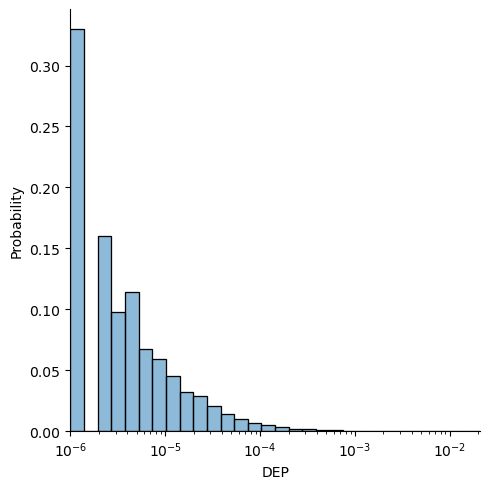

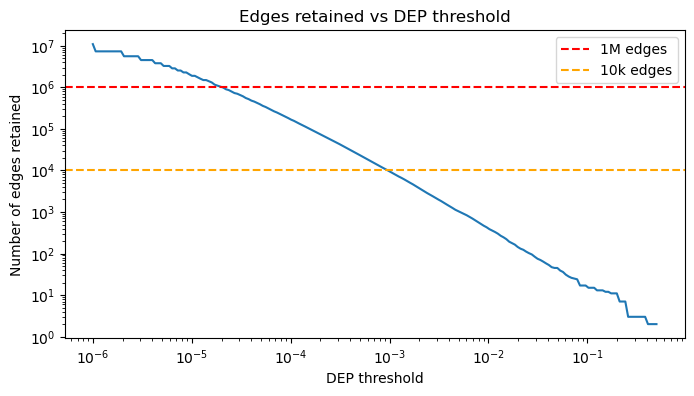

DEP_low (~1M): DEP ≈ 2.076586e-05, edges retained = 991526
DEP_high (~10k): DEP ≈ 9.513847e-04, edges retained = 10147


In [2]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP ≈ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")

Saved data/undir_trials/24h/network.txt with 991526 edges


Single Test Run Template

In [22]:
# --- new split if needed ---

fpath = Path('data/undir_trials/24h/network.txt')
save_dir = Path(f'data/undir_trials/24h/tests')
file_path = save_dir / f"split_{seed}.pkl"
if file_path.is_file():
    print(f"Split already exists for seed: {seed}. Exiting...")
    sys.exit()

G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath, frac=.25, seed=seed, weight='cov')

save_dir.mkdir(parents=True, exist_ok=True)
with open(file_path, 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Saved split → {file_path}")

Nodes: 115456
Edges: 991526


Sampling spatial non-edges:   0%|          | 0/247863 [00:00<?, ?edge/s]

Sampling spatial non-edges:   0%|          | 0/743591 [00:00<?, ?edge/s]

Wrote training graph: 115334 nodes, 743591 edges
Saved split → data\undir_trials\24h\tests\split_42.pkl


In [6]:
# --- run test ---

print(f"Using seed: {seed}")

split_dir = Path(f'data/undir_trials/24h/tests')
file_path = split_dir / f"split_{seed}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
            
p, q, dim = 4, 0.25, 192
weighted = True
feats = 'all'
auc, _ = pipeline.run_pipeline(f'data/undir_trials/24h/tests/train_{seed}.txt', 
                                train_neg, test_pos, test_neg, seed=seed,
                                p=p, q=q, dim=192, workers=6, weighted=weighted,
                                features=feats, G=G)

feats_id = '_'.join(feats) if isinstance(feats, list) else feats
with open(f'data/undir_trials/24h/tests/score_seed{seed}-p{p}-q{q}-dim{dim}-w{weighted}-feats_{feats_id}.txt', 'w') as f:
        f.write(str(auc))

Using seed: 21


  0%|          | 0/1146360 [00:00<?, ?it/s]

Took 00:01:21.86 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:08:30.47 to train embeddings
Embeddings generated: 114636 nodes, dim=192
Running Infomap...
Done.
Assigned 64 communities
Training matrix: 1477738 samples x 235 features
[emb+geo+cat+cbg+comm (hadamard)]  AUC = 0.6548


Embedding/Geographical Distance Comparison

In [ ]:
# --- get results from revised pipeline ---

# getting test/train split once outside the loop
train_neg, test_pos, test_neg = pipeline.prepare_data(
    'data/undir_trials/thresholded_networks/0_network.txt'
)

# saving split for later
split_dir = Path('data/undir_trials/dim_test')
split_dir.mkdir(parents=True, exist_ok=True)
split_file = split_dir / 'data_splits.pkl'
print("Saving current data splits to disk...")
with open(split_file, 'wb') as f:
    pickle.dump((train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Successfully saved to: {split_file}")

print("Training graph complete. Moving to pipeline...\n")

# path for saving later
dir_path = Path("data/undir_trials/dim_test/")
dir_path.mkdir(parents=True, exist_ok=True)

for vec_size in np.arange(48, 209, 16):
    print(f'--- Vector Size: {vec_size} ---')
    # put through pipeline + record computation time
    start_time = time.perf_counter()
    cur_scores, cur_emb = pipeline.run_pipeline(
        'train.txt', train_neg, test_pos, test_neg, dim=vec_size, workers=8, mode='SparseOTF'
    )
    end_time = time.perf_counter()
    comptime = end_time - start_time
    print(f'Computation Time for Vector Size {vec_size}: {comptime/60:.3f} minutes.\n')

    # saving so i dont have to wait two hours to rerun it if the kernel breaks
    print('Saving...')
    for data, label in [(cur_scores, 'scores'), (cur_emb, 'embeddings')]:
        with open(dir_path / f"{label}_{int(vec_size)}.pkl", 'wb') as f:
            pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)
    print(f'Saved for vector size {vec_size}.\n')

Nodes: 115355
Edges: 1015920


sampling non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

About to write training graph...
Wrote training graph: 115270 nodes, 507933 edges
Training graph complete. Moving to pipeline...
--- Vector Size: 48 ---


  0%|          | 0/1152700 [00:00<?, ?it/s]

...

create_training_data label=1:   0%|          | 0/507933 [00:00<?, ?edge/s]

create_training_data label=0:   0%|          | 0/507933 [00:00<?, ?edge/s]

predicting probabilities:   0%|          | 0/4 [00:00<?, ?operator/s]

computing AUC:   0%|          | 0/4 [00:00<?, ?operator/s]

avg       : 0.5962
hadamard  : 0.9039
w-l1      : 0.8427
w-l2      : 0.8460
Computation Time for Vector Size 208: 919.974


Saving...
Saved for vector size 208.


In [ ]:
# --- load stuff in ---

# --- metadata ---
print('Loading metadata...')

# minimizing ram usage
dtypes = {
    'LAT_ORIGIN': 'float32',
    'LNG_ORIGIN': 'float32',
    'ORIGIN': 'category',
    'DESTINATION': 'category'
}

orig_df = pd.read_csv(data, 
    usecols=['ORIGIN', 'DESTINATION', 'TAXONOMY_ORIGIN', 'TAXONOMY_DESTINATION', 'LAT_ORIGIN', 'LNG_ORIGIN'],
    dtype=dtypes
)

# --- splits ---

print("Loading existing data splits from disk...")
split_file = Path('data/undir_trials/dim_test/data_splits.pkl')
with open(split_file, 'rb') as f:
    train_neg, test_pos, test_neg = pickle.load(f)

# --- scores + embeddings ---
print("Loading pipeline results...")
scores_dict = {}
emb_dict = {}
results_dir = Path("data/undir_trials/dim_test")

# iterate through the files to read them in
for file_path in results_dir.glob("*.pkl"):
    # extract label and vector size
    filename_parts = file_path.stem.split('_')
    
    if len(filename_parts) == 2:
        try:
            label = filename_parts[0]
            vec_size = int(filename_parts[1])
        except ValueError:
            print(f"Skipping {file_path}: second part is not a number.")
            continue
        
        # load data from pickle file
        with open(file_path, 'rb') as f:
            result = pickle.load(f)
            
        # store in appropriate dict keyed by vec_size
        if label == 'scores':
            scores_dict[vec_size] = result
        elif label == 'embeddings':
            emb_dict[vec_size] = result
        else:
            print(f"Warning: Unknown label '{label}' in filename '{file_path.name}'. Skipping.")

    else:
        print(f"Warning: Unexpected filename format '{file_path.name}'. Skipping.")

# combine into df (set dict keys as rows and sort)
scores_df = pd.DataFrame.from_dict(scores_dict, orient='index').sort_index()
emb_df = pd.DataFrame.from_dict(emb_dict, orient='index').sort_index()

# --- compute embedding distances ---

# create node catalog for O(1) lookups
node_catalog = orig_df[['ORIGIN', 'TAXONOMY_ORIGIN', 'LAT_ORIGIN', 'LNG_ORIGIN']].drop_duplicates(subset=['ORIGIN'])
node_catalog = node_catalog.set_index('ORIGIN')

# combine positive and negative test samples into one list
eval_pairs = test_pos + test_neg 

# convert to df
eval_df = pd.DataFrame(eval_pairs, columns=['NODE_A', 'NODE_B'])

# label for whether or not it's an edge
eval_df['IS_EDGE'] = [1] * len(test_pos) + [0] * len(test_neg)

import numpy as np

# map taxonomy
eval_df['TAXONOMY_A'] = eval_df['NODE_A'].map(node_catalog['TAXONOMY_ORIGIN'])
eval_df['TAXONOMY_B'] = eval_df['NODE_B'].map(node_catalog['TAXONOMY_ORIGIN'])

eval_df['LAT_A'] = eval_df['NODE_A'].map(node_catalog['LAT_ORIGIN'])
eval_df['LON_A'] = eval_df['NODE_A'].map(node_catalog['LNG_ORIGIN'])
eval_df['LAT_B'] = eval_df['NODE_B'].map(node_catalog['LAT_ORIGIN'])
eval_df['LON_B'] = eval_df['NODE_B'].map(node_catalog['LNG_ORIGIN'])

# drop NaNs
eval_df = eval_df.dropna(subset=['LAT_A', 'LON_A', 'LAT_B', 'LON_B'])

# redefine dist_km for all nodes in the combined df
eval_df['DIST_KM'] = haversine(eval_df['LAT_A'], eval_df['LON_A'], eval_df['LAT_B'], eval_df['LON_B'])

# --- create new df with all info for each vec_size --- 
print('Combining DataFrames...')
combined_dfs = {}
correlations = {}
for vec_size in emb_df.index:
    print(f"Analyzing Vector Size: {vec_size}")

    temp_df = eval_df.copy() # temporary df for this iteration
    emb_mapping = emb_df.loc[vec_size].to_dict() # extract embeddings as dict
    
    # map embeddings to origin and destination nodes
    temp_df['EMB_A'] = temp_df['NODE_A'].map(emb_mapping)
    temp_df['EMB_B'] = temp_df['NODE_B'].map(emb_mapping)
    
    # handle nodes that were removed by pipeline LCC filtering and became NaNs
    temp_df = temp_df.dropna(subset=['EMB_A', 'EMB_B']).reset_index(drop=True)
    
    # --- add cosine distance ---

    # convert to ndarray for speed
    A = np.array(temp_df['EMB_A'].tolist())
    B = np.array(temp_df['EMB_B'].tolist())
    
    # calculate dot product and norms for all rows
    dot_product = np.sum(A * B, axis=1)
    norm_A = np.linalg.norm(A, axis=1)
    norm_B = np.linalg.norm(B, axis=1)
    
    # protect against division by zero
    denominator = norm_A * norm_B
    denominator[denominator == 0] = 1e-10 
    
    # apply back to df
    temp_df['EMB_DIST_COS'] = 1 - (dot_product / denominator)

    # creating category for same vs different POI (Fixed column names)
    temp_df['SAME_POI'] = temp_df['TAXONOMY_A'] == temp_df['TAXONOMY_B']

    # --- correlations (spearman) ---
    corr, p_value = spearmanr(temp_df['EMB_DIST_COS'], temp_df['DIST_KM'])
    correlations[vec_size] = corr

    # save
    combined_dfs[vec_size] = temp_df

print("\nData loading complete.")


Loading metadata...
Loading existing data splits from disk...
Loading pipeline results...
Skipping data\undir_trials\dim_test\data_splits.pkl: second part is not a number.
Combining DataFrames...
Analyzing Vector Size: 48
Analyzing Vector Size: 64
Analyzing Vector Size: 80
Analyzing Vector Size: 96
Analyzing Vector Size: 112
Analyzing Vector Size: 128
Analyzing Vector Size: 144
Analyzing Vector Size: 160
Analyzing Vector Size: 176
Analyzing Vector Size: 192
Analyzing Vector Size: 208

Data loading complete.


C:\Users\User\AppData\Local\Temp\ipykernel_21468\3321315926.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


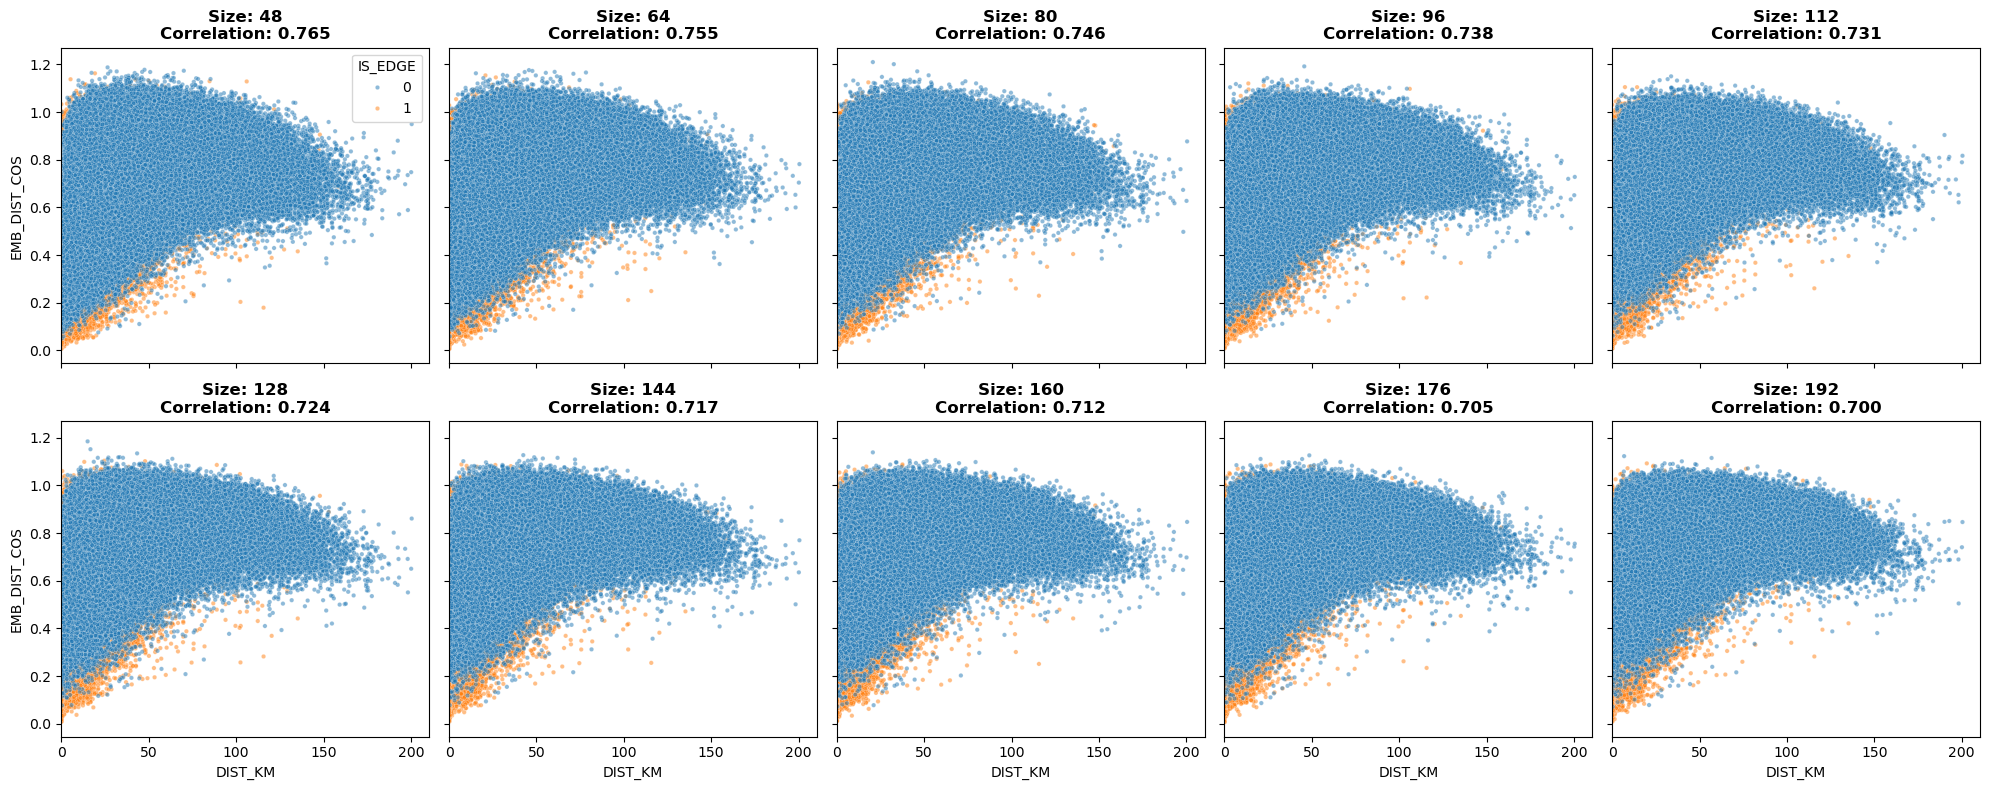

In [10]:
# --- plotting ---

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten() 

# iterate through dfs and plot for each
for i, ((vec_size, df), ax) in enumerate(zip(combined_dfs.items(), axes)):

    ax = axes[i]
    
    sns.scatterplot(
        data=df, 
        x='DIST_KM',
        y='EMB_DIST_COS',
        hue='IS_EDGE',
        hue_order=[0, 1],
        ax=ax, 
        alpha=0.5, 
        s=10,
        legend=(i == 0) # only draw the legend on the first plot
    )
    
    # setting limits
    ax.set_xlim(0, df['DIST_KM'].max() * 1.05) 

    # add title with correlation value
    corr_val = correlations[vec_size] 
    ax.set_title(f"Size: {vec_size}\nCorrelation: {corr_val:.3f}", fontweight='bold')

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/geo_vs_emb_scatter.png')


Generating t-SNE for vector size 192...


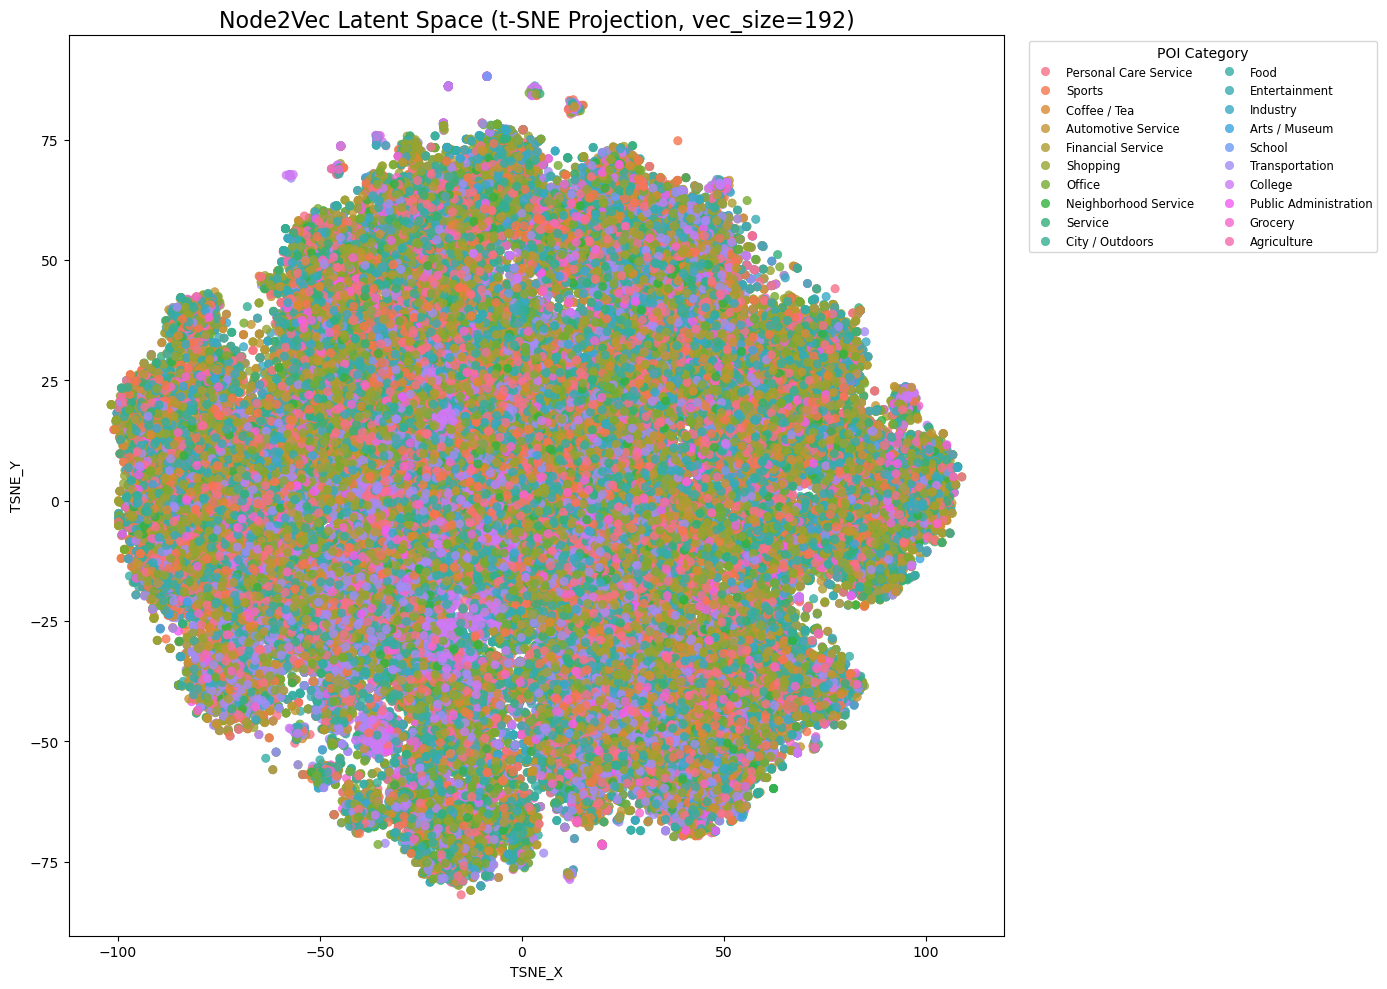

In [8]:
# --- POI t-SNE map ---

# Pick one vector size to visualize
target_vec_size = 192
print(f"Generating t-SNE for vector size {target_vec_size}...")

# 1. Extract the embeddings for this size
# emb_df.loc[target_vec_size] gives us a Series where index = Node IDs, values = Vectors
emb_series = emb_df.loc[target_vec_size]

# Convert to a clean DataFrame
node_df = pd.DataFrame({
    'NODE_ID': emb_series.index,
    'EMBEDDING': emb_series.values
})

# 2. Map the POI Category from your existing node_catalog
node_df['POI_TYPE'] = node_df['NODE_ID'].map(node_catalog['TAXONOMY_ORIGIN'])

# Drop any nodes that are missing a POI type
node_df = node_df.dropna(subset=['POI_TYPE']).reset_index(drop=True)

# 3. Extract the raw matrix for t-SNE
X_matrix = np.stack(node_df['EMBEDDING'].values)

# 4. Run t-SNE to squash from 48D down to 2D
# Note: perplexity=30 is standard, you can tweak it between 5 and 50 if the plot looks weird
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X_matrix)

# 5. Add the new 2D coordinates back to our dataframe
node_df['TSNE_X'] = X_2d[:, 0]
node_df['TSNE_Y'] = X_2d[:, 1]

# --- Plotting ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Find exactly how many unique POI categories we need to color
num_pois = node_df['POI_TYPE'].nunique()

# 2. Generate a maximally distinct color palette using HUSL
# This mathematically spaces out the hues so they are as different as possible
distinct_palette = sns.color_palette("husl", num_pois)

# Made the figure slightly wider to comfortably fit a large legend
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=node_df,
    x='TSNE_X',
    y='TSNE_Y',
    hue='POI_TYPE',
    palette=distinct_palette,
    alpha=0.8,
    edgecolor=None
)

plt.title(f'Node2Vec Latent Space (t-SNE Projection, vec_size={target_vec_size})', fontsize=16)

# 3. Format the legend so it's readable even with many categories
plt.legend(
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    title="POI Category",
    fontsize='small',
    title_fontsize='medium',
    ncol=(2 if num_pois > 15 else 1)
)

plt.tight_layout()
plt.savefig(f'data/undir_trials/imgs/tsne_nodes_{target_vec_size}.png')
plt.show()

Revised Negative Edge Sampling

Attribute check: ('22j-223@62k-26r-c5z', {'latitude': 41.957599, 'longitude': -70.665682, 'poi_type': 'Food', 'unique_visits': 174, 'total_visits': 311})
Nodes: 115355
Edges: 1015920


Sampling spatial non-edges:   0%|          | 0/57677 [00:00<?, ?edge/s]

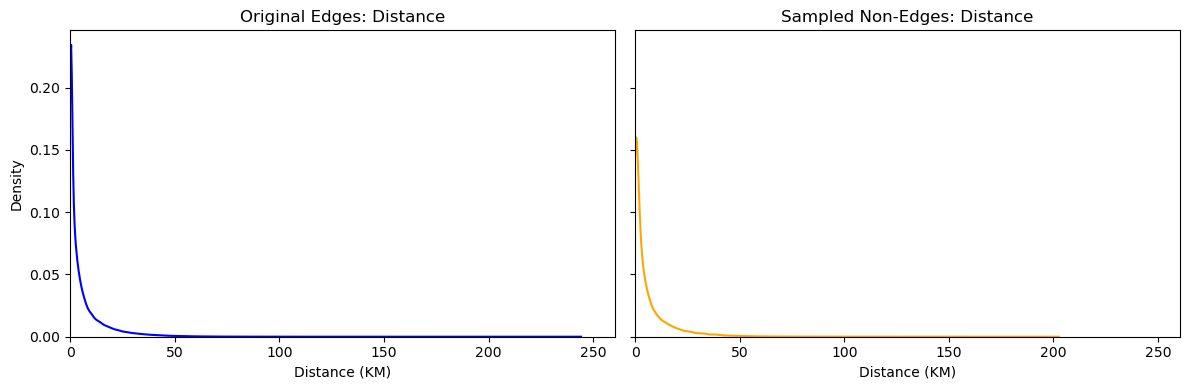

In [ ]:
# Plots/Verification

from pipeline import distribution_finder, sample_non_edges_dist_controlled, load
G = load(r'data/undir_trials/thresholded_networks/0_network.txt')

# Generate the sample 
distrs, sets = distribution_finder(G, bins=50)
dist_distr = distrs[0]
sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)

original_distances = list(nx.get_edge_attributes(G, 'DIST_KM').values())

locs = []
for u, v in sample:
    lat_u, lon_u = G.nodes[u]['latitude'], G.nodes[u]['longitude']
    lat_v, lon_v = G.nodes[v]['latitude'], G.nodes[v]['longitude']
    locs.append((lat_u, lon_u, lat_v, lon_v))

sampled_distances = [haversine((lat1, lon1), (lat2, lon2)) for (lat1, lon1, lat2, lon2) in locs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
pd.Series(original_distances).plot.kde(bw_method='scott', ax=axes[0], title='Original Edges: Distance', color='blue')
pd.Series(sampled_distances).plot.kde(bw_method='scott', ax=axes[1], title='Sampled Non-Edges: Distance', color='orange')
axes[0].set_xlabel('Distance (KM)')
axes[1].set_xlabel('Distance (KM)')
axes[0].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(r'data\undir_trials\imgs\distance_distr_comp.png')
plt.show()

In [2]:
# Re-running pipeline

# --- prep ---
fpath = Path(r'data/undir_trials/thresholded_networks/0_network.txt')
G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath)

# --- metadata only ---
auc_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo'])
auc_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['cat'])
auc_vis, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['visits'])
auc_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat'])
auc_all_metadata, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat', 'visits'])

# --- embeddings only ---
auc_emb, emb_map = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb'])

# --- embeddings + metadata ---
auc_emb_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo'], embedding_map=emb_map)
auc_emb_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat'], embedding_map=emb_map)
auc_all, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat', 'visits'], embedding_map=emb_map)

# --- results table ---
results = [
    (['geo'],                          auc_geo),
    (['cat'],                          auc_cat),
    (['visits'],                       auc_vis),
    (['geo', 'cat'],                   auc_geo_cat),
    (['geo', 'cat', 'visits'],         auc_all_metadata),
    (['emb'],                          auc_emb),
    (['emb', 'geo'],                   auc_emb_geo),
    (['emb', 'geo', 'cat'],            auc_emb_geo_cat),
    (['emb', 'geo', 'cat', 'visits'],  auc_all),
]

df_results = pd.DataFrame(results, columns=['Features', 'AUC'])
df_results['Features'] = df_results['Features'].apply(lambda x: ' + '.join(x))
df_results['AUC'] = df_results['AUC'].round(4)

# flag embedding inclusion
df_results['Includes_Emb'] = df_results['Features'].str.contains('emb').map({True: 'with_emb', False: 'without_emb'})

Attribute check: ('zzy-222@62k-2wx-kxq', {'latitude': 41.986673, 'longitude': -70.700233, 'poi_type': 'City / Outdoors', 'unique_visits': 327, 'total_visits': 849})
Nodes: 115355
Edges: 1015920


Sampling spatial non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

Sampling spatial non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

Wrote training graph: 115270 nodes, 507933 edges
Training matrix: 1015866 samples x 1 features
[geo]  AUC = 0.5011
Training matrix: 1015866 samples x 40 features
[cat]  AUC = 0.5177
Training matrix: 1015866 samples x 2 features
[visits]  AUC = 0.5134
Training matrix: 1015866 samples x 41 features
[geo+cat]  AUC = 0.5178
Training matrix: 1015866 samples x 43 features
[geo+cat+visits]  AUC = 0.5179


  0%|          | 0/1152700 [00:00<?, ?it/s]

Took 00:00:35.56 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:06:20.77 to train embeddings
Embeddings generated: 115270 nodes, dim=128
Training matrix: 1015866 samples x 128 features
[emb (hadamard)]  AUC = 0.5896
Using precomputed embeddings: 115270 nodes
Training matrix: 1015866 samples x 129 features
[emb+geo (hadamard)]  AUC = 0.6060
Using precomputed embeddings: 115270 nodes
Training matrix: 1015866 samples x 169 features
[emb+geo+cat (hadamard)]  AUC = 0.6092
Using precomputed embeddings: 115270 nodes
Training matrix: 1015866 samples x 171 features
[emb+geo+cat+visits (hadamard)]  AUC = 0.6096


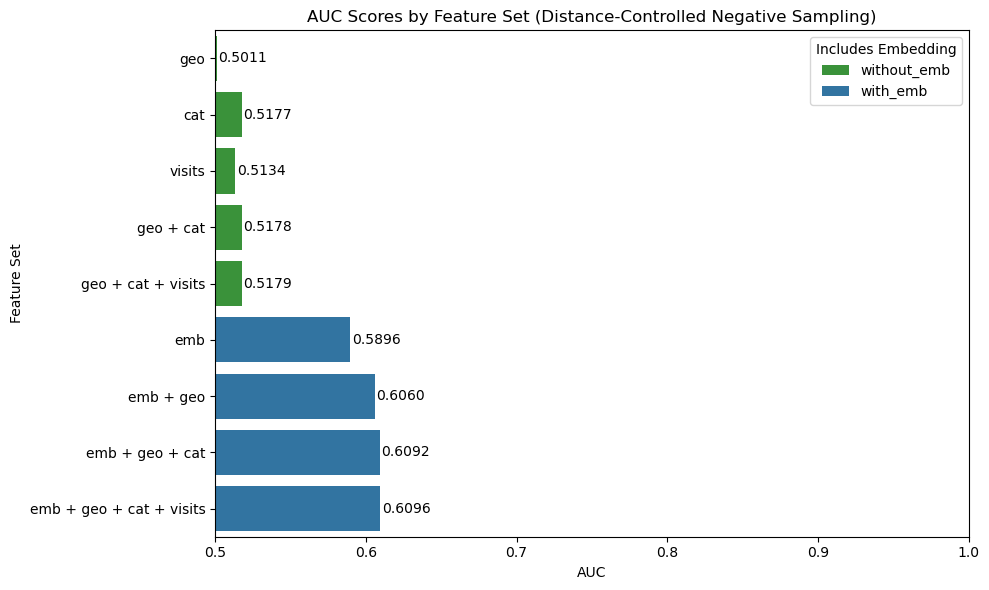

In [3]:
# AUC bar plot color-coded by embedding inclusion
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='AUC', y='Features', hue='Includes_Emb', dodge=False, palette={'with_emb':'tab:blue','without_emb':'tab:green'})
plt.title('AUC Scores by Feature Set (Distance-Controlled Negative Sampling)')
plt.xlabel('AUC')
plt.ylabel('Feature Set')
plt.xlim(left=0.5, right=1)
for i, value in enumerate(df_results['AUC']):
    plt.text(value + 0.001, i, f"{value:.4f}", va='center')
plt.legend(title='Includes Embedding')
plt.tight_layout()
plt.savefig('data/undir_trials/imgs/auc_by_feature_barplot.png')
plt.show()

Sequential Hyperparameter Sweep

In [ ]:
# Sequential Hyperparameter Sweep: p → q → dim

# Saves the split to disk at the start so it survives kernel restarts.

sweep_dir = Path('data/undir_trials/hparam_sweep')
sweep_dir.mkdir(parents=True, exist_ok=True)

# Persist the split so it can be reloaded without re-running prepare_data
with open(sweep_dir / 'sweep_split.pkl', 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Split saved → {sweep_dir / 'sweep_split.pkl'}")

FPATH   = 'train.txt'
WORKERS = 8
MODE    = 'PreComp'   # matches the baseline cell

# Walk params that match the baseline defaults in run_pipeline
WALK_KWARGS = dict(num_walks=10, walk_length=80, window_size=10)

P_VALUES   = [0.25, 0.50, 1, 2, 4]
Q_VALUES   = [0.25, 0.50, 1, 2, 4]
DIM_VALUES = [64, 96, 160, 192]

def run_phase(param_name, param_values, fixed):
    fixed_str = ', '.join(f"{k}={v}" for k, v in fixed.items())
    print(f"\n{'='*60}")
    print(f"PHASE: sweeping {param_name}  |  fixed: {fixed_str}")
    print(f"  values: {param_values}")
    print(f"{'='*60}")

    rows = []
    for val in param_values:
        kw = {**fixed, param_name: val}
        print(f"\n  [{param_name}={val}] starting ...", flush=True)
        t0 = time.perf_counter()

        auc, _ = pipeline.run_pipeline(
            FPATH, train_neg, test_pos, test_neg,
            G=G, features=['emb'], mode=MODE, workers=WORKERS,
            **WALK_KWARGS, **kw
        )

        elapsed = time.perf_counter() - t0
        print(f"  [{param_name}={val}]  AUC = {auc:.4f}   ({elapsed/60:.1f} min)", flush=True)
        rows.append({**kw, 'auc': auc, 'time_min': elapsed / 60})

    df = pd.DataFrame(rows)
    best_val = df.loc[df['auc'].idxmax(), param_name]
    print(f"\n  --> Best {param_name} = {best_val}  (AUC = {df['auc'].max():.4f})")
    print(df[[param_name, 'auc', 'time_min']].to_string(index=False))
    return df, best_val

# ── Phase 1: p sweep ──────────────────────────────────────────
p_df, best_p = run_phase('p', P_VALUES, fixed={'q': 1, 'dim': 128})
with open(sweep_dir / 'phase1_p_sweep.pkl', 'wb') as f:
    pickle.dump(p_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase1_p_sweep.pkl'}")

# ── Phase 2: q sweep ──────────────────────────────────────────
q_df, best_q = run_phase('q', Q_VALUES, fixed={'p': best_p, 'dim': 128})
with open(sweep_dir / 'phase2_q_sweep.pkl', 'wb') as f:
    pickle.dump(q_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase2_q_sweep.pkl'}")

# ── Phase 3: dim sweep ────────────────────────────────────────
dim_df, best_dim = run_phase('dim', DIM_VALUES, fixed={'p': best_p, 'q': best_q})
with open(sweep_dir / 'phase3_dim_sweep.pkl', 'wb') as f:
    pickle.dump(dim_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase3_dim_sweep.pkl'}")

# ── Consolidate ───────────────────────────────────────────────
all_results = {
    'phase1_p':   p_df,
    'phase2_q':   q_df,
    'phase3_dim': dim_df,
    'best': {'p': best_p, 'q': best_q, 'dim': int(best_dim)},
}
with open(sweep_dir / 'all_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f, pickle.HIGHEST_PROTOCOL)

print(f"\n{'='*60}")
print("SWEEP COMPLETE")
print(f"  best p   = {best_p}")
print(f"  best q   = {best_q}")
print(f"  best dim = {int(best_dim)}")
print(f"  baseline (p=1, q=1, dim=128): AUC = {p_df.loc[p_df['p']==1, 'auc'].values[0]:.4f}")
print(f"  all results → {sweep_dir / 'all_sweep_results.pkl'}")
print(f"{'='*60}")

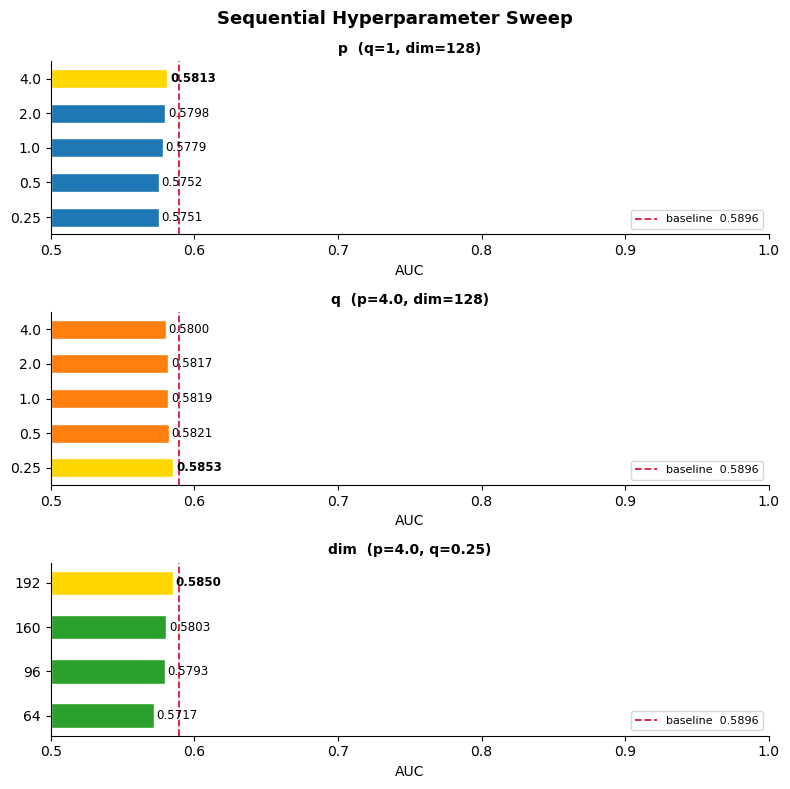

In [8]:
sweep_dir = Path('data/undir_trials/hparam_sweep')
with open(sweep_dir / 'all_sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

p_df   = sweep_results['phase1_p']
q_df   = sweep_results['phase2_q']
dim_df = sweep_results['phase3_dim']
best   = sweep_results['best']

try:
    baseline = auc_emb
except NameError:
    baseline = 0.5896

phases = [
    (p_df,   'p',   f"p  (q=1, dim=128)",                        'tab:blue'),
    (q_df,   'q',   f"q  (p={best['p']}, dim=128)",              'tab:orange'),
    (dim_df, 'dim', f"dim  (p={best['p']}, q={best['q']})",      'tab:green'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
fig.suptitle('Sequential Hyperparameter Sweep', fontsize=13, fontweight='bold')

for ax, (df, param, title, color) in zip(axes, phases):
    labels = [str(v) for v in df[param]]
    aucs   = df['auc'].values
    best_i = aucs.argmax()

    colors = [color] * len(aucs)
    colors[best_i] = 'gold'

    ax.barh(labels, aucs - 0.5, left=0.5, color=colors, edgecolor='white', height=0.55)

    ax.axvline(baseline, color='crimson', linestyle='--', linewidth=1.3,
               label=f'baseline  {baseline:.4f}')

    for i, val in enumerate(aucs):
        ax.text(val + 0.002, i, f'{val:.4f}',
                va='center', fontsize=8.5,
                fontweight='bold' if i == best_i else 'normal')

    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('AUC')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/hparam_sweep_results.png', bbox_inches='tight', dpi=150)
plt.show()

Weighted (node2vec+)

In [ ]:
seed = 21
fpath = Path('data/undir_trials/thresholded_networks/0_network.txt')
BEST_PARAMS = dict(p=4, q=0.25, dim=192)

# function for efficiency
def run_weighted_test(weight, compress=False):
    print(f"Starting test: weight={weight}, compress={compress}")
    split_dir = Path(f'data/undir_trials/weight_trials/{weight}')
    split_dir.mkdir(parents=True, exist_ok=True)
    weightmode = 'log' if compress else 'reg'

    # read back in if already exists
    load_dir = split_dir / f'{weightmode}_split.pkl'
    if load_dir.is_file():
        print("Reading back from disk...")
        with open(load_dir, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
    else:
        G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath, seed=seed, compress=compress, weight=weight)
        with open(load_dir, 'wb') as f:
            pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
        print(f"Saved split → {split_dir / f'{weightmode}_split.pkl'}")

    auc, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, seed=seed,
                                **BEST_PARAMS, workers=6, weighted=True)

    with open(split_dir / f'{weightmode}_score.txt', 'w') as f:
        f.write(str(auc))

    # move + rename training graph to save it
    shutil.move('train.txt', split_dir / f'{weightmode}_train.txt')

    print('Saved score + training graph.\n')

# dep
run_weighted_test('dep')
run_weighted_test('dep', True)

# cov
run_weighted_test('cov')
run_weighted_test('cov', True)

Starting test: weight=dep, compress=False
Nodes: 115355
Edges: 1015920


Sampling spatial non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

Sampling spatial non-edges:   0%|          | 0/507933 [00:00<?, ?edge/s]

Wrote training graph: 115270 nodes, 507933 edges
Saved split → data\undir_trials\weight_trials\dep\reg_split.pkl


  0%|          | 0/1129670 [00:00<?, ?it/s]

...

Wrote training graph: 115270 nodes, 507933 edges
Saved split → data\undir_trials\weight_trials\cov\log_split.pkl


  0%|          | 0/1129670 [00:00<?, ?it/s]

Took 00:00:43.23 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:07:28.58 to train embeddings
Embeddings generated: 112967 nodes, dim=192
Training matrix: 995443 samples x 192 features
[emb (hadamard)]  AUC = 0.6058
Saved score + training graph.

